# Load packages

In [2]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad


In [ ]:
import ace_tools as tools

# Import data

In [3]:
#adata = ad.read_h5ad("/storage/users/data/PANC/H5AD_file/adata_filtered_no2D_hvg_clust_time_pub.h5ad")
#'/storage/users/data/PANC/MA_time_adata_10066.h5ad'
#adata = ad.read_h5ad("/storage/users/data/PANC/H5AD_file/adata_filtered_no2D_hvg_clust_time_pub.h5ad")
#adata = sc.read('/storage/users/data/PANC/H5AD_file/adata_filtered_no2D_hvg_clust_palantir.h5ad')
adata = ad.read_h5ad("/storage/users/data/PANC/H5AD_file/adata_filtered_no2D_hvg_clust_time_pub.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 6235 × 1992
    obs: 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_cmo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scores', 'predicted_doublets', 'outlier', 'leiden', 't', 'seg', 'edge', 'milestones', 't_sd'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'CMO', 'gene_symbol', 'mito', 'ribo', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'condition_colors', 'draw_graph', 'graph', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'milestones_colors', 'neighbors', 'pca', 'ppt', 'pseudotime_list', 'seg_colors', 'umap'
    obsm: 'X_R', 'X_draw_graph_fa', 'X_palantir', 

#  Count number of cells treated with GEM in the leiden clusters and report percentage of all cells within the cluster

204
160
411
332


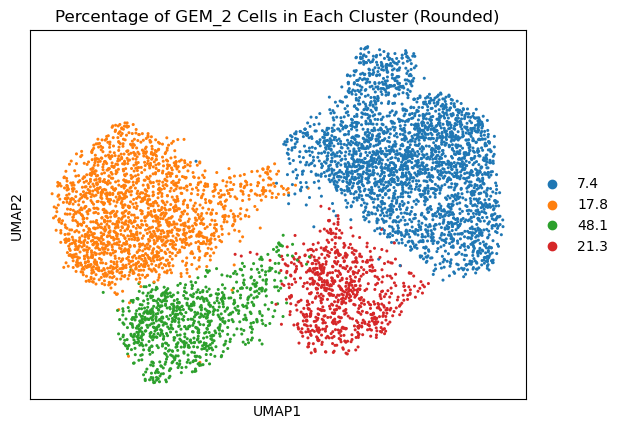

In [5]:
# Assuming 'adata' is your AnnData object
# Calculate the percentage of 'GEM_2' cells in each Leiden cluster
clusters = adata.obs['leiden'].unique()
percent_gem = {}

for cluster in clusters:
    cluster_cells = adata[adata.obs['leiden'] == cluster]
    num_cells_in_cluster = len(cluster_cells)
    #gem_cells_in_cluster = cluster_cells[cluster_cells.obs['condition'] == 'GEM_2']
    gem_cells_in_cluster = cluster_cells[cluster_cells.obs['condition'].str.contains('GEM', regex=True)]
    num_gem_cells_in_cluster = len(gem_cells_in_cluster)
    print(num_gem_cells_in_cluster)
    # Calculate and round the percentage to one decimal place
    percent_gem[cluster] = round(num_gem_cells_in_cluster / num_cells_in_cluster * 100, 1)

# Add the calculated percentages as a new column to the adata.obs
adata.obs['percent_gem'] = adata.obs['leiden'].map(percent_gem)


# Plotting the percentage on UMAP
sc.pl.umap(adata, color='percent_gem', title='Percentage of GEM_2 Cells in Each Cluster (Rounded)')



'percent_gem' is not numeric. Attempting to convert.


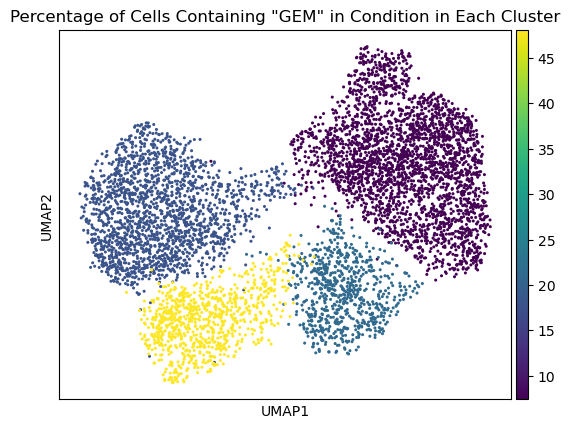

In [6]:
# Check if 'percent_gem' column exists
if 'percent_gem' not in adata.obs.columns:
    print("percent_gem column does not exist in adata.obs")
else:
    # Check for NaN values and replace them with a default value (e.g., 0)
    if adata.obs['percent_gem'].isna().any():
        print("NaN values found in 'percent_gem'. Replacing with 0.")
        adata.obs['percent_gem'].fillna(0, inplace=True)

    # Ensure that 'percent_gem' contains numeric data
    if not pd.api.types.is_numeric_dtype(adata.obs['percent_gem']):
        print("'percent_gem' is not numeric. Attempting to convert.")
        adata.obs['percent_gem'] = pd.to_numeric(adata.obs['percent_gem'], errors='coerce')

    # Plotting the percentage on UMAP
    sc.pl.umap(adata, color='percent_gem', title='Percentage of Cells Containing "GEM" in Condition in Each Cluster')


In [7]:
import pandas as pd
import scipy.stats as stats

# Store results
fisher_results = []

clusters = adata.obs['leiden'].unique()

# Count total GEM and non-GEM cells in the dataset
total_gem_cells = (adata.obs['condition'].str.contains('GEM', regex=True)).sum()
total_non_gem_cells = len(adata) - total_gem_cells

for cluster in clusters:
    cluster_cells = adata.obs['leiden'] == cluster
    
    # Count GEM and non-GEM cells in the cluster
    num_gem_in_cluster = (adata.obs.loc[cluster_cells, 'condition'].str.contains('GEM', regex=True)).sum()
    num_non_gem_in_cluster = cluster_cells.sum() - num_gem_in_cluster

    # Count GEM and non-GEM cells outside the cluster
    num_gem_outside_cluster = total_gem_cells - num_gem_in_cluster
    num_non_gem_outside_cluster = total_non_gem_cells - num_non_gem_in_cluster

    # Construct the contingency table
    contingency_table = [[num_gem_in_cluster, num_non_gem_in_cluster],
                         [num_gem_outside_cluster, num_non_gem_outside_cluster]]
    
    # Perform Fisher’s exact test
    odds_ratio, p_value = stats.fisher_exact(contingency_table, alternative='greater')

    # Store results
    fisher_results.append([cluster, num_gem_in_cluster, num_non_gem_in_cluster, 
                           num_gem_outside_cluster, num_non_gem_outside_cluster, 
                           odds_ratio, p_value])

# Convert results to DataFrame
fisher_df = pd.DataFrame(fisher_results, 
                         columns=['Cluster', 'GEM in Cluster', 'Non-GEM in Cluster',
                                  'GEM outside Cluster', 'Non-GEM outside Cluster',
                                  'Odds Ratio', 'P-Value'])




In [8]:
print(fisher_df)

  Cluster  GEM in Cluster  Non-GEM in Cluster  GEM outside Cluster  \
0       0             204                2557                  903   
1       3             160                 592                  947   
2       2             411                 444                  696   
3       1             332                1535                  775   

   Non-GEM outside Cluster  Odds Ratio        P-Value  
0                     2571    0.227151   1.000000e+00  
1                     4536    1.294557   4.673515e-03  
2                     4684    6.229691  2.327350e-111  
3                     3593    1.002733   4.981367e-01  


In [ ]:
# Display results

tools.display_dataframe_to_user(name="Fisher's Exact Test Results", dataframe=fisher_df)